In [150]:
"""RPA resistance model: one parameter set, one time axis.

    dA/dt = alpha * (mu - B)                       integral feedback on setpoint
    dB/dt = beta1*(1 - e(t))*A - beta2*B           therapy blocks the A->B arm
    dC/dt = C * (c1 - c2 * max(mu - B, 0))         one-sided effect on the tumor

A = compensatory angiogenic factors, B = blood vessel density, C = tumor size.

Treatment enters as a fractional block e in [0,1) of the A->B arm, matching the
arrow the drug is drawn on. Adaptation is untouched (B* = mu comes from
dA/dt = 0), but A* = beta2*mu/(beta1*(1-e)) rises to compensate. During
treatment the loop gain is alpha*beta1*(1-e), so
    omega_n = sqrt(alpha*beta1*(1-e)),  zeta = beta2 / (2*omega_n),
and the drop rate at onset is exactly -beta2*e.
"""
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """
    Save a matplotlib figure to the PLOTS_DIR as a PDF file.

    Args:
        fig: The matplotlib figure object to save.
        name: The filename (without extension) or with .pdf extension.
    """
    # Ensure the filename ends with .pdf
    if not name.lower().endswith(".pdf"):
        name = f"{name}.pdf"
    save_path = PLOTS_DIR / name
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Figure saved to {save_path}")


# --- shared parameters ----------------------------------------------------
# beta2 = 6 with alpha = 16 keeps zeta between 0.84 and 1.37 over the dose set
# below: no visible overshoot, and every curve back at setpoint inside 8 weeks.
alpha, beta1, beta2, mu = 16.0, 1.0, 6.0, 1.0
t_rx, e = 2.0, 0.40           # treatment start (weeks) and fractional block
c1, c2 = 1.04, 11.5           # tumor growth rate, sensitivity to vessel deficit
T = 8.0                       # shared time axis, weeks
doses = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]  # Figure 1E; e is the middle one


def rhs(t, y):
    A, B, C = y
    gain = beta1 * (1 - (e if t >= t_rx else 0.0))
    return [alpha * (mu - B),
            gain * A - beta2 * B,
            C * (c1 - c2 * max(mu - B, 0.0))]


sol = solve_ivp(rhs, [0, T], [beta2 * mu / beta1, mu, 1.0],
                max_step=0.005, dense_output=True)
t = np.linspace(0, T, 1600)
A, B, C = sol.sol(t)


def style(ax):
    ax.axvspan(t_rx, T, color='0.93', zorder=0)     # treatment window
    ax.set_xlim(0, T)
    ax.set_xticks(range(int(T) + 1))
    ax.set_xlabel('time (weeks)')
    ax.spines[['top', 'right']].set_visible(False)

Figure saved to ../plots/Figure1_B.pdf


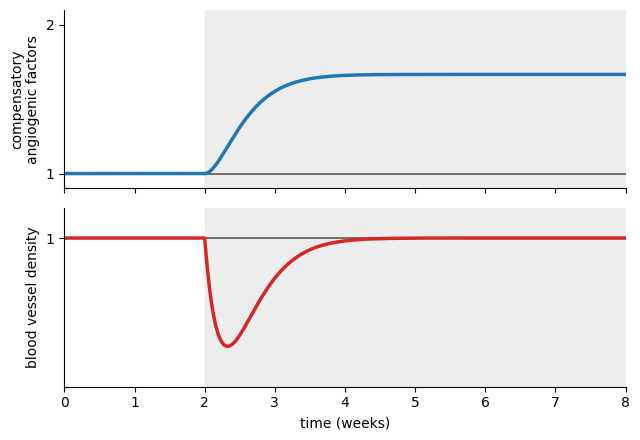

In [156]:
# --- Figure 1B: the adapting variables ------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(6.5, 4.5), sharex=True)
for ax, y, color, label in [
        (axes[0], A / A[0], 'tab:blue', 'compensatory\nangiogenic factors'),
        (axes[1], B / B[0], 'tab:red', 'blood vessel density')]:
    style(ax)
    ax.axhline(1, color='0.35', lw=1.2)             # setpoint
    ax.plot(t, y, color=color, lw=2.5)
    ax.set_yticks([1, 2])
    ax.set_ylabel(label)
axes[0].set_ylim(0.9, 2.1)
axes[1].set_ylim(0.60, 1.08)
axes[0].set_xlabel('')
fig.tight_layout()
save_fig(fig, "Figure1_B")

Figure saved to ../plots/Figure1_C.pdf


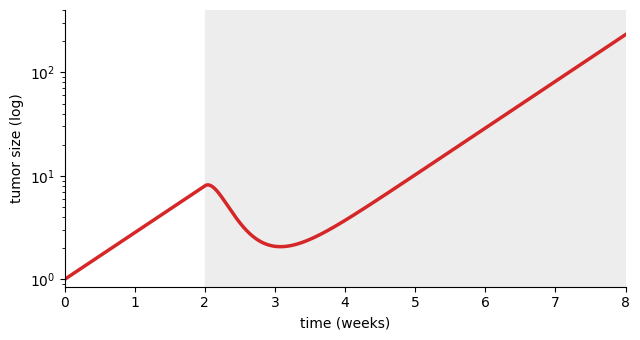

In [152]:
# --- Figure 1C: the tumor -------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 3.5))
style(ax)
ax.plot(t, C, color='tab:red', lw=2.5)
ax.set_yscale('log')
ax.set_ylim(0.85, 400)
ax.set_ylabel('tumor size (log)')
fig.tight_layout()
save_fig(fig, "Figure1_C")

Figure saved to ../plots/Figure1_E.pdf


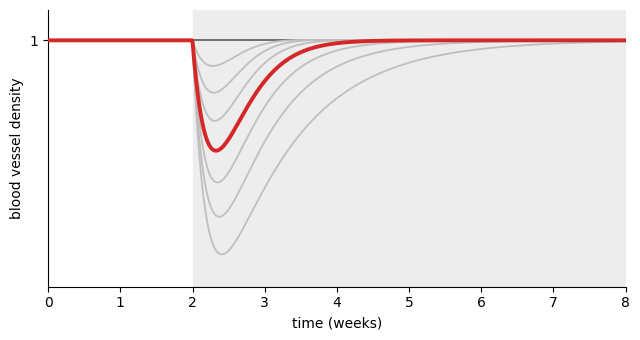

In [158]:
# --- Figure 1E: same model, one curve per dose ----------------------------
fig, ax = plt.subplots(figsize=(6.5, 3.5))
style(ax)
ax.axhline(1, color='0.35', lw=1.2, zorder=1)       # setpoint

for dose in doses:
    f = lambda s, y: [alpha * (mu - y[1]),
                      beta1 * (1 - (dose if s >= t_rx else 0.0)) * y[0] - beta2 * y[1]]
    Bd = solve_ivp(f, [0, T], [beta2 * mu / beta1, mu],
                   max_step=0.005, dense_output=True).sol(t)[1]
    ref = np.isclose(dose, e)
    # bring ref to the front of the plot
    ax.plot(t, Bd, color='tab:red' if ref else '0.75', lw=2.8 if ref else 1.3,
            zorder=3 if ref else 2)

ax.set_ylim(0.35, 1.08)
ax.set_yticks([1])
ax.set_ylabel('blood vessel density')
fig.tight_layout()
save_fig(fig, "Figure1_E")

Figure saved to ../plots/Figure1_F.pdf


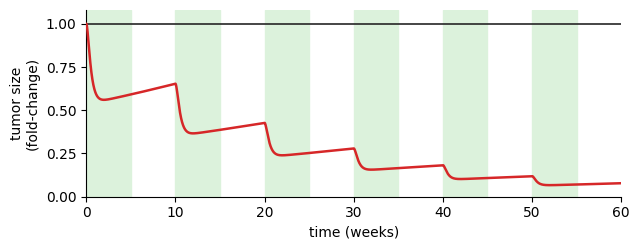

In [165]:
# --- Figure 1F: one drug, cycled on and off -------------------------------
# The same single feedback loop, with the drug applied in alternating blocks
# (shaded = on). While on, the blocked A->B arm drives B below setpoint and the
# tumor shrinks; adaptation closes the deficit and shrinkage stops, giving the
# within-block plateau. The off block lets A relax back to baseline, so the next
# on block opens a fresh deficit and the response repeats.
P, T_cyc = 5.0, 60.0            # weeks per block, total span
c1_cyc, c2_cyc = 0.02, 2.5      # growth and kill rates on this longer schedule


def rhs_cyc(s, y):
    A, B, C = y
    on = 1.0 if (s // P) % 2 == 0 else 0.0
    return [alpha * (mu - B),
            beta1 * (1 - e * on) * A - beta2 * B,
            C * (c1_cyc - c2_cyc * on * max(mu - B, 0.0))]


t_cyc = np.linspace(0, T_cyc, 6000)
A_cyc, B_cyc, C_cyc = solve_ivp(rhs_cyc, [0, T_cyc],
                                [beta2 * mu / beta1, mu, 1.0],
                                max_step=0.005, dense_output=True).sol(t_cyc)

fig, ax = plt.subplots(figsize=(6.5, 2.6))
for k in range(0, int(T_cyc // P), 2):          # shade the on blocks
    ax.axvspan(k * P, (k + 1) * P, color='#dcf2dc', zorder=0)
ax.axhline(1, color='0.15', lw=1.2, zorder=1)
ax.plot(t_cyc, C_cyc, color='tab:red', lw=1.8, zorder=3)
ax.set_xlim(0, T_cyc)
ax.set_ylim(0, 1.08)
ax.set_xticks(range(0, int(T_cyc) + 1, 10))
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel('time (weeks)')
ax.set_ylabel('tumor size\n(fold-change)')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_fig(fig, "Figure1_F")